In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import os
import sys
from pathlib import Path
import functools

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import lsstypes as types
code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,code_dir)
import tools
import plotting_tools

In [3]:
# !ls /dvs_ro/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/glam-uchuu-v2-altmtl/mock150/

In [4]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

In [5]:
def plot_covariance_checks(kind, imocks_set1, version_set1, imocks_set2, version_set2, **stats_kws):
    # get covariance of mocks from set 1
    fns = [tools.get_stats_fn(**stats_kws, version=version_set1, kind=kind, imock=imock) for imock in imocks_set1]
    fns = [fn for fn in fns if os.path.exists(fn)]
    mocks = [types.read(fn) for fn in fns]
    sns = [mock.get(ells=0).values('shotnoise').mean() for mock in mocks]
    print(f'Shotnoise is {np.mean(sns):.0f}+-{np.std(sns):.0f}')
    covariance_set1 = types.cov(mocks)

    # get covariance of mocks from set 2
    fns = [tools.get_stats_fn(**stats_kws, version=version_set2, kind=kind, imock=imock) for imock in imocks_set2]
    fns = [fn for fn in fns if os.path.exists(fn)]
    mocks = [types.read(fn) for fn in fns]
    sns = [mock.get(ells=0).values('shotnoise').mean() for mock in mocks]
    print(f'Shotnoise is {np.mean(sns):.0f}+-{np.std(sns):.0f}')
    covariance_set2 = types.cov(mocks)

    # match covariances
    observable = covariance_set1.observable.select(k=slice(0, None, 5)).select(k=(0., 0.4))
    covariance_set1 = covariance_set1.at.observable.match(observable)
    covariance_set2 = covariance_set2.at.observable.match(observable)

    # plot
    kw = dict(ytransform=lambda x, y: x**4 * y)
    fig = covariance_set1.plot_diag(**kw, show=False, color='C0')
    fig.suptitle(f'{stats_kws['tracer']} power spectrum covariance in {stats_kws['region']} {stats_kws['zrange'][0]:.1f} < z < {stats_kws['zrange'][1]:.1f}', fontsize=12)
    covariance_set2.plot_diag(**kw, fig=fig, color='C1')
    lax = fig.axes
    ax = lax[1]
    for i,ilabel in enumerate([version_set1,version_set2]):
        ax.plot([],[],color=f'C{i}',label=ilabel)
    ax.legend()
    # covariance_set1.plot(corrcoef=True, show=True)

In [6]:
analysis = 'full_shape'
project = f'{analysis}/base'
regions = ['GCcomb', 'NGC', 'SGC']

stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = (0,2,4)
ells4bk = ((0,0,0), (2,0,2))

# Dark time

In [7]:
tracers = ['LRG', 'ELG_LOPnotqso', 'QSO']
version_set1 = 'glam-uchuu-v2-altmtl'
version_set2 = 'holi-v3-altmtl'

# get mock indices to use for mock covariance estimation
glam_imocks = np.loadtxt('../helper_scripts/glam-uchuu-v2-altmtl_dark-time_imocks_for_covariance.txt',dtype=int)
holi_imocks = np.loadtxt('../helper_scripts/holi-v3-altmtl_dark-time_imocks_for_covariance.txt',dtype=int)
print(len(glam_imocks),len(holi_imocks))

878 859


Shotnoise is 3247+-9
Shotnoise is 3224+-20


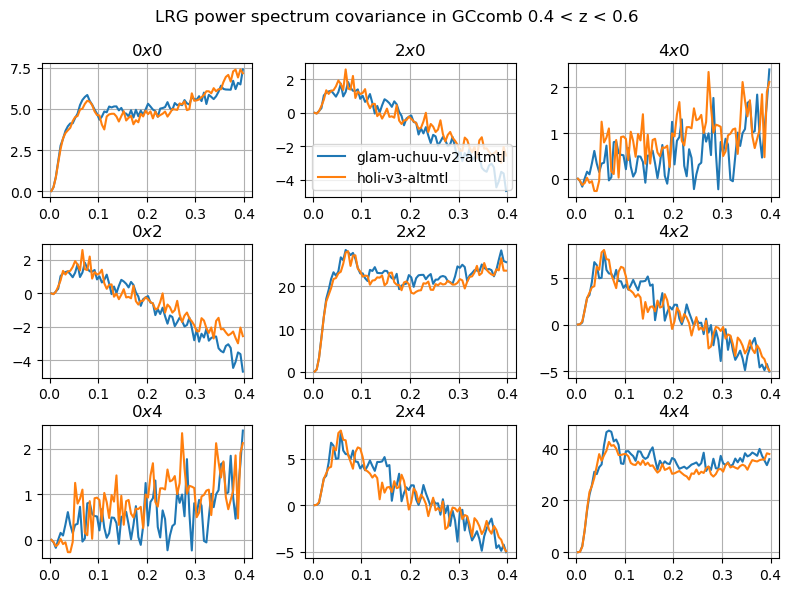

Shotnoise is 3297+-7
Shotnoise is 3293+-11


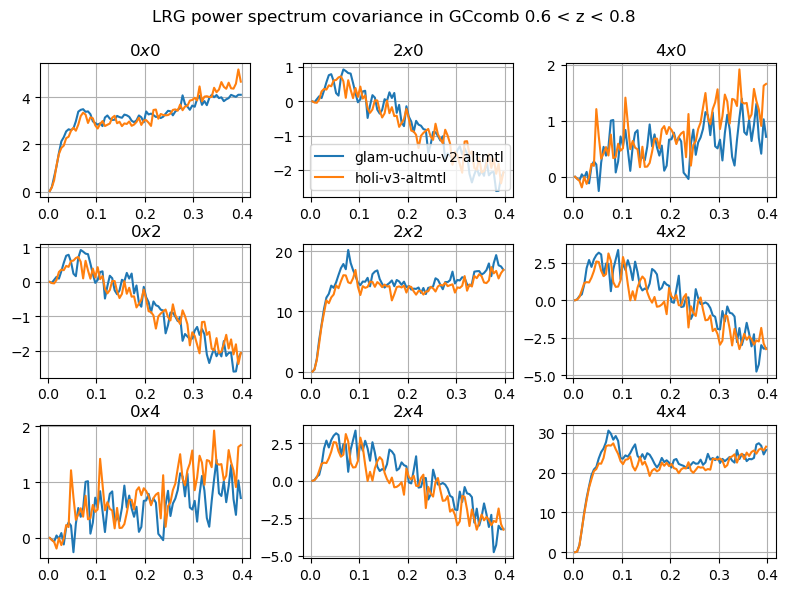

Shotnoise is 6549+-10
Shotnoise is 6504+-19


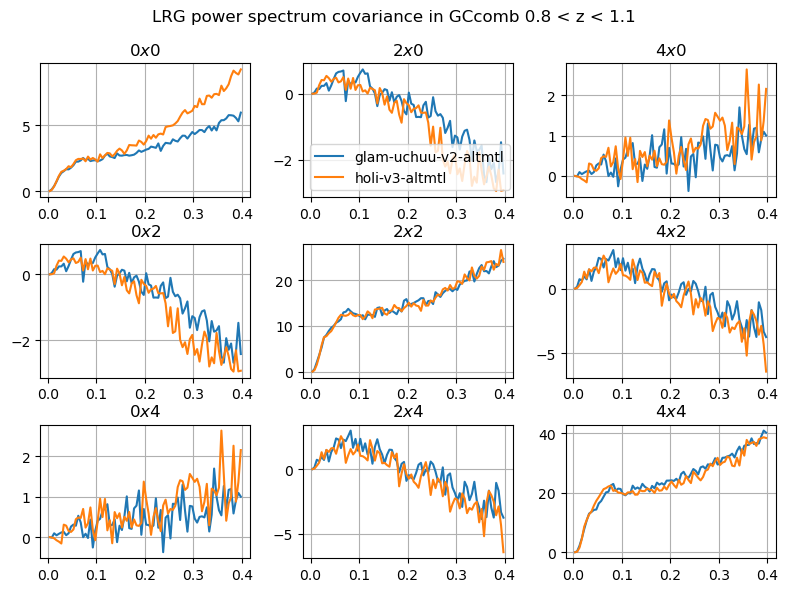

Shotnoise is 3280+-13
Shotnoise is 3256+-22


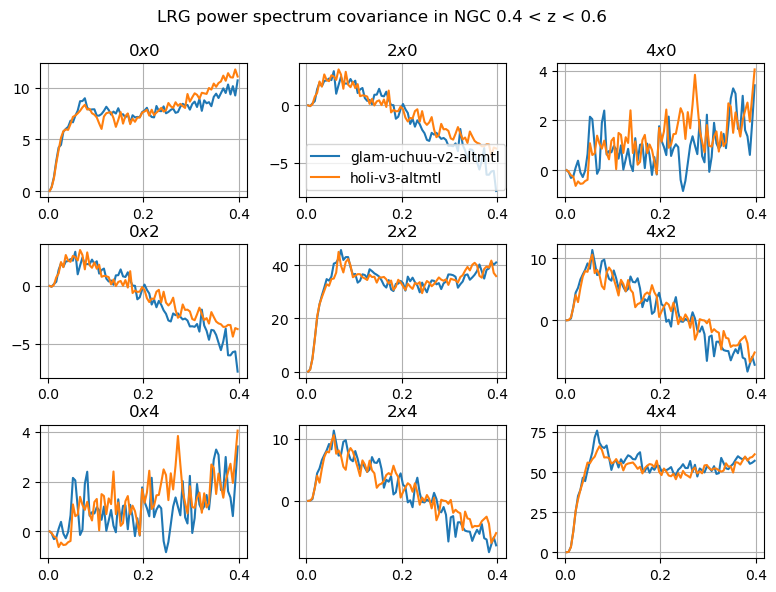

Shotnoise is 3332+-11
Shotnoise is 3327+-14


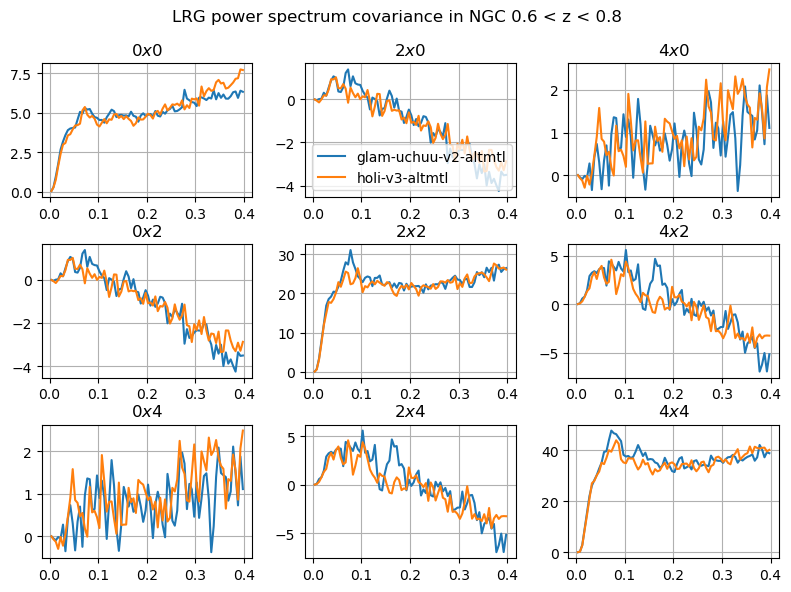

Shotnoise is 6610+-17
Shotnoise is 6561+-24


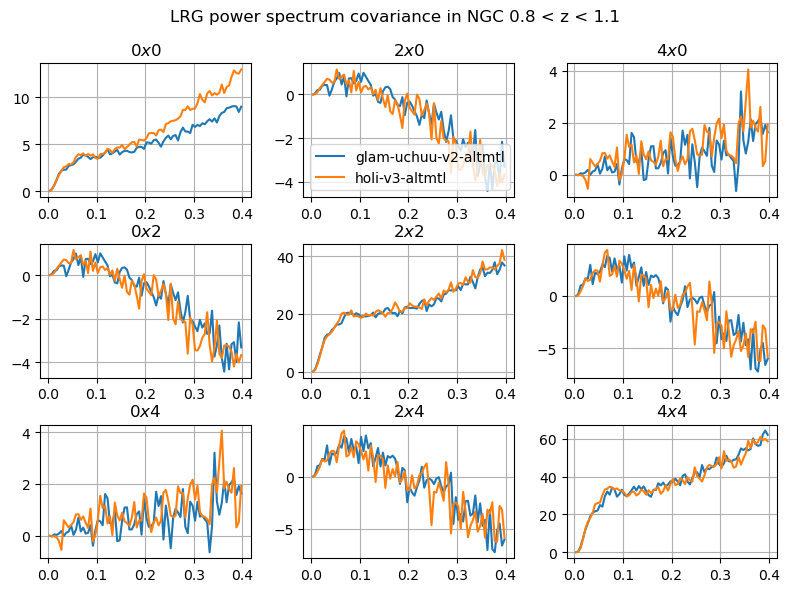

Shotnoise is 3186+-19
Shotnoise is 3163+-26


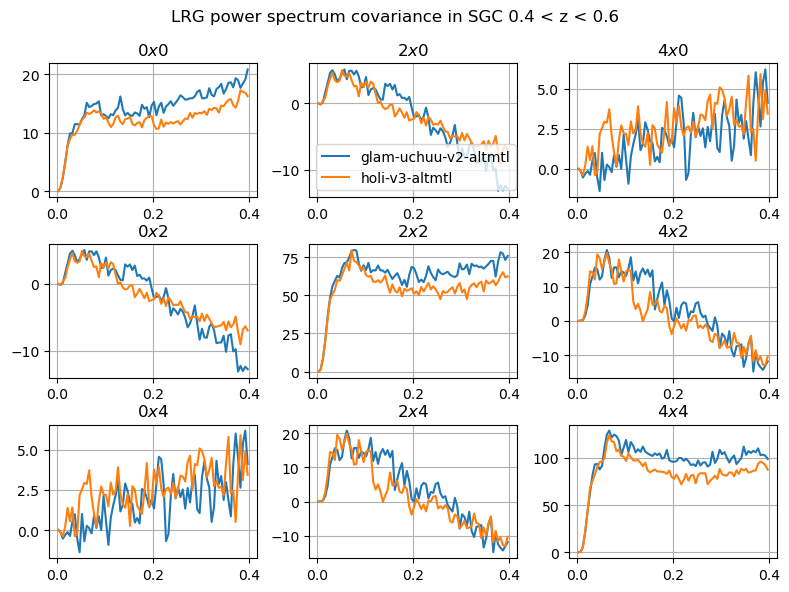

Shotnoise is 3232+-16
Shotnoise is 3229+-18


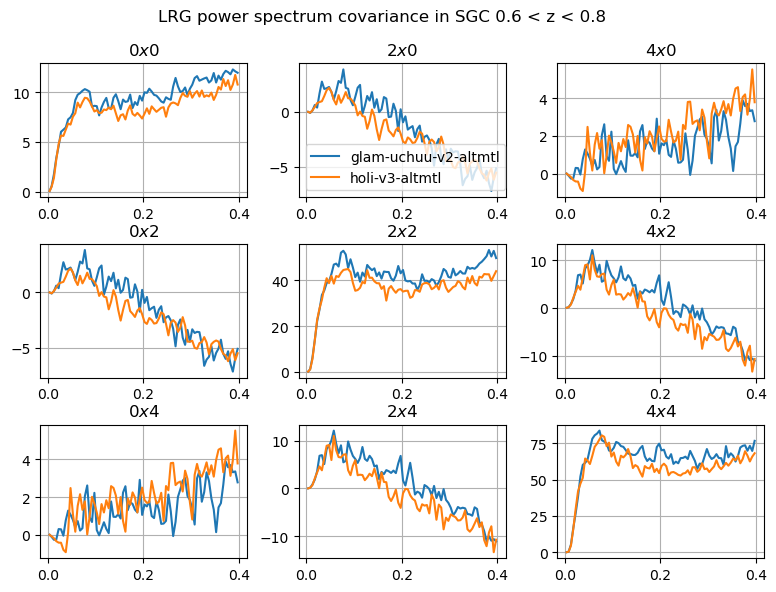

Shotnoise is 6434+-26
Shotnoise is 6394+-31


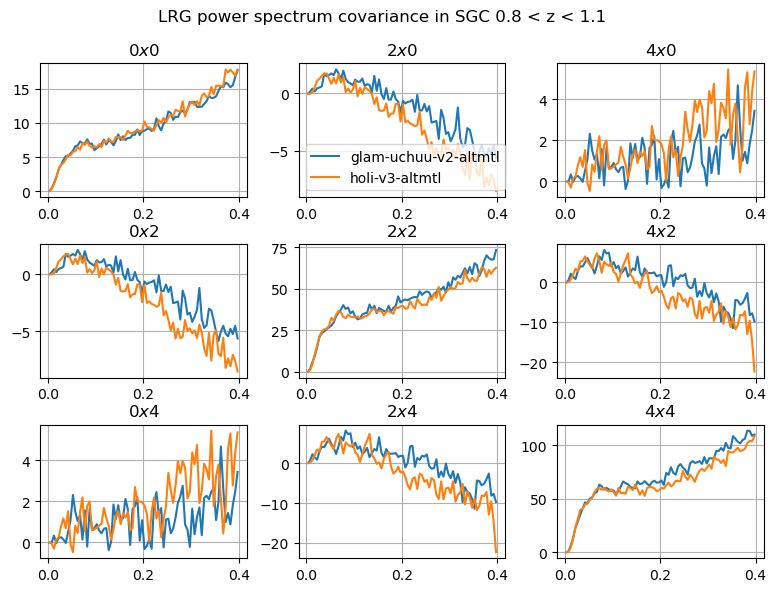

Shotnoise is 4740+-7
Shotnoise is 4764+-9


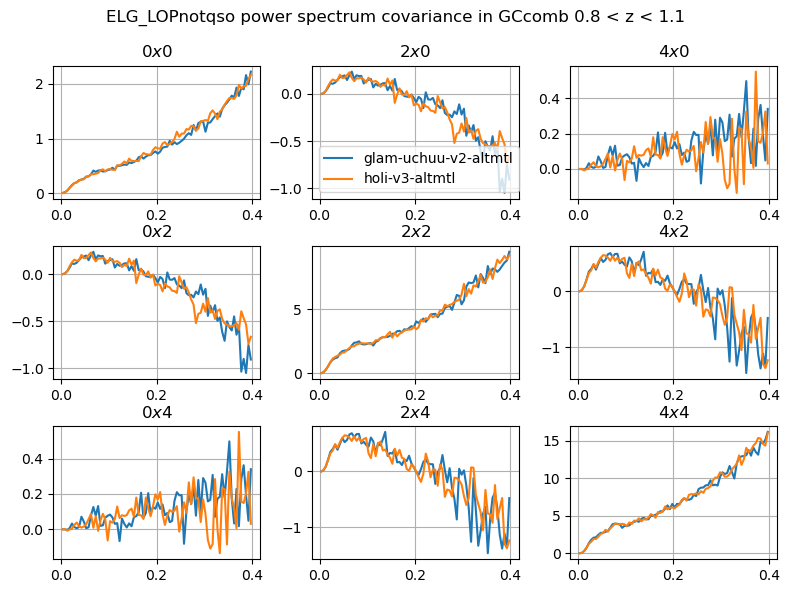

Shotnoise is 6908+-9
Shotnoise is 6989+-12


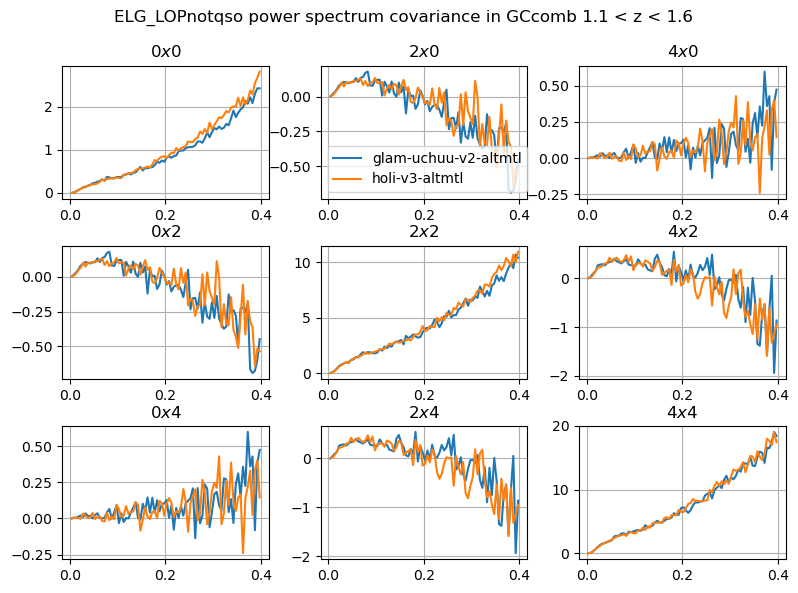

Shotnoise is 4828+-9
Shotnoise is 4854+-11


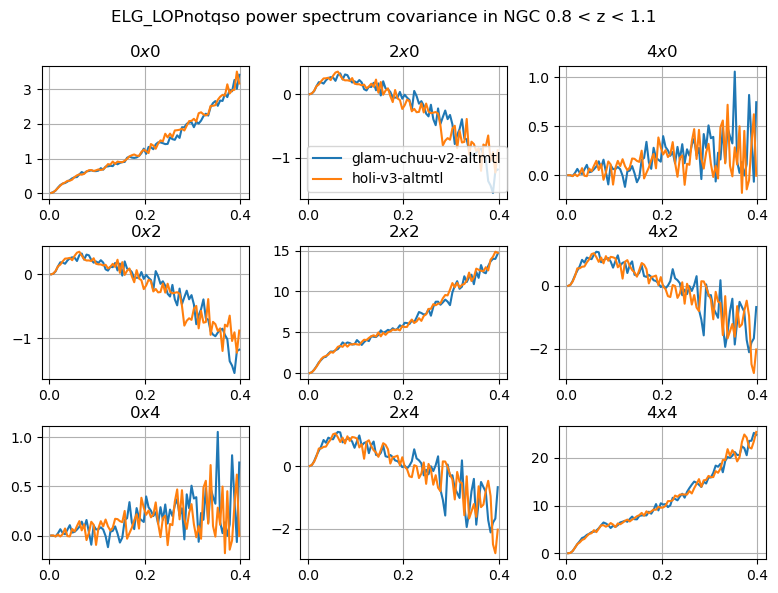

Shotnoise is 7043+-11
Shotnoise is 7125+-13


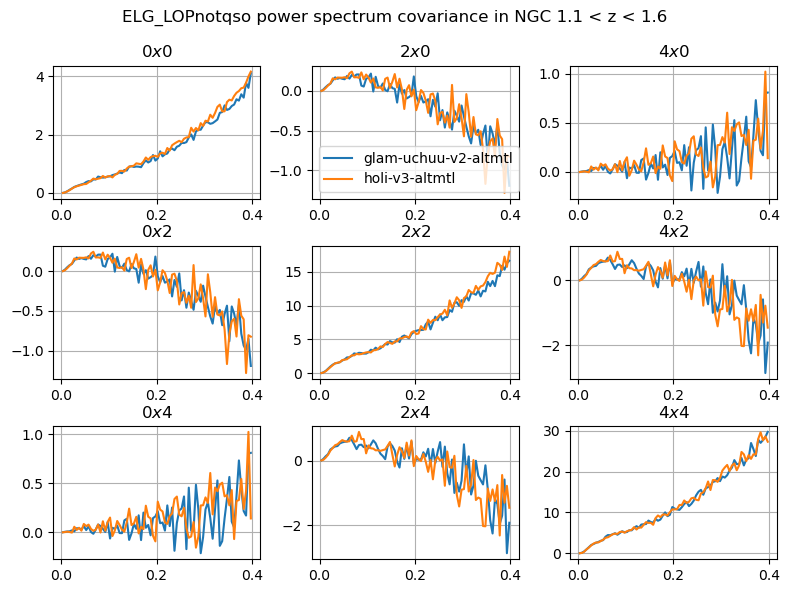

Shotnoise is 4574+-11
Shotnoise is 4596+-12


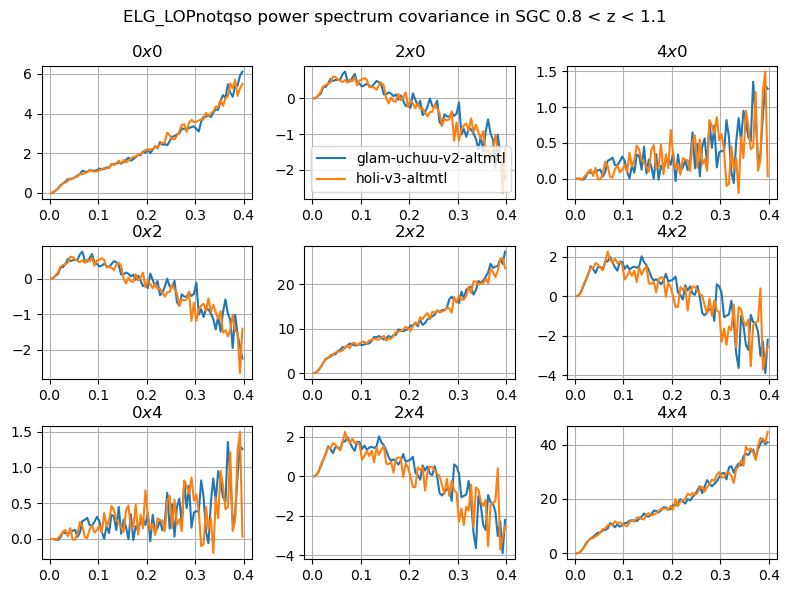

Shotnoise is 6660+-13
Shotnoise is 6740+-16


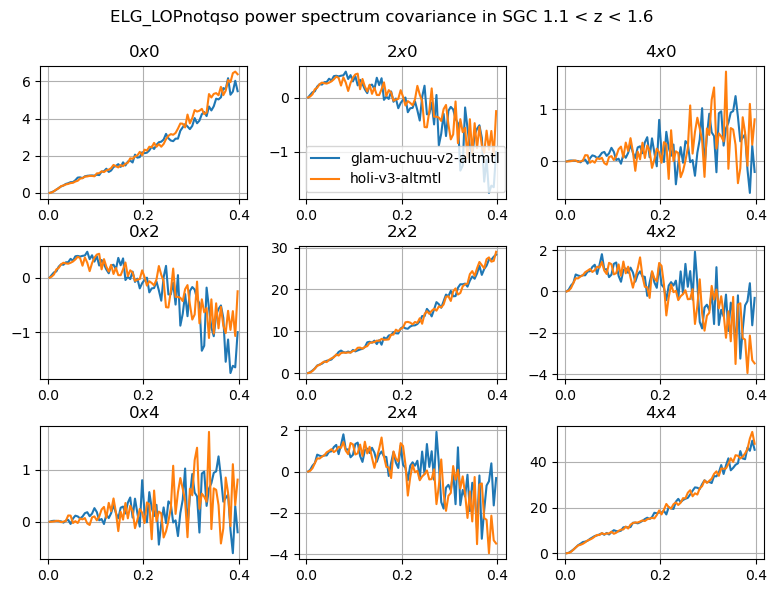

Shotnoise is 39866+-44
Shotnoise is 39778+-54


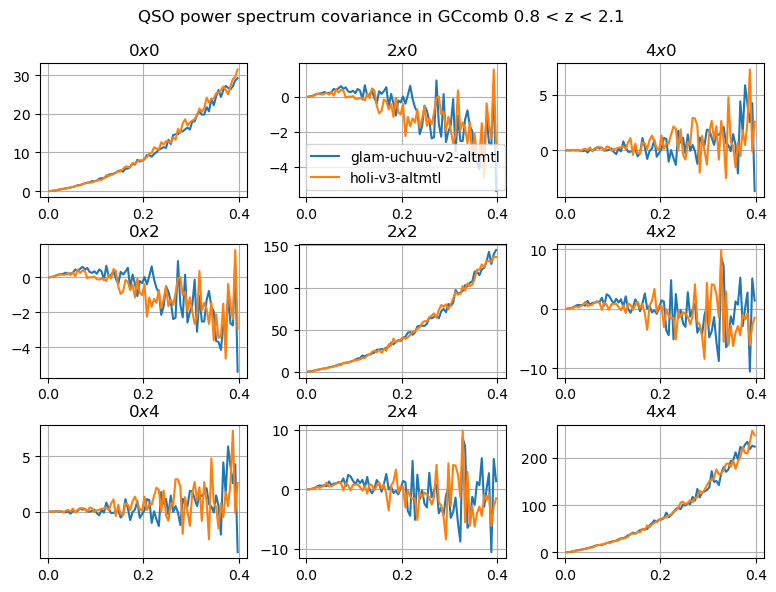

Shotnoise is 39885+-53
Shotnoise is 39789+-62


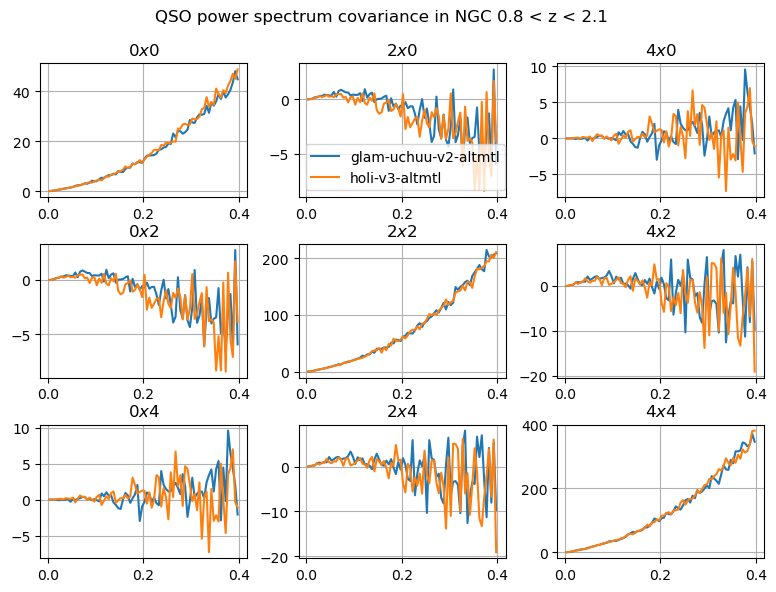

Shotnoise is 39830+-74
Shotnoise is 39756+-80


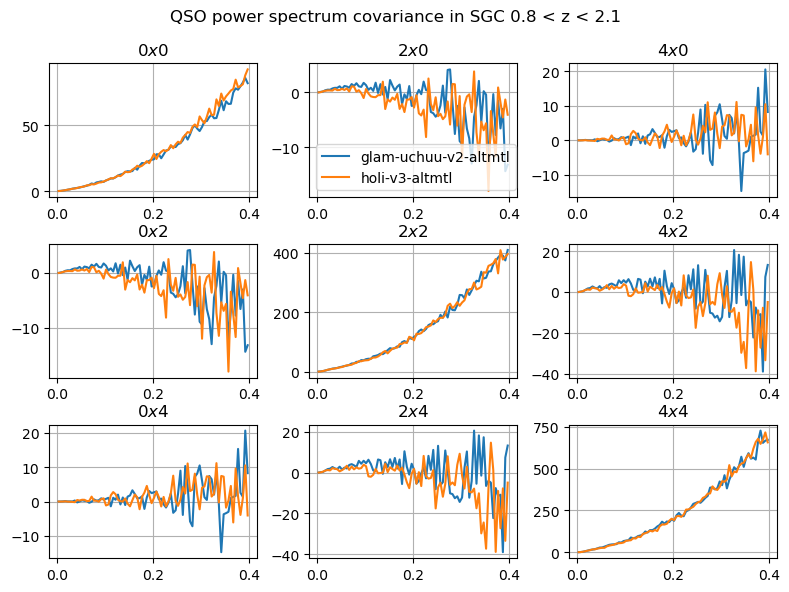

In [9]:
# now plot covariance
kind = 'mesh2_spectrum'
pp = PdfPages(plot_dir / 'check_covariance_diagonals_glam_and_holi_dark.pdf')
for tracer in tracers:
    for region in regions:
        zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
        for iz, zrange in enumerate(zranges): 
            stats_kws = dict(stats_dir=stats_dir, tracer=tracer, project=project, zrange=zrange, region=region, weight='default-FKP')
            plot_covariance_checks(kind, glam_imocks, version_set1, holi_imocks, version_set2, **stats_kws)
            
            fig = plt.gcf()
            pp.savefig(fig,bbox_inches='tight')
            plt.show()
pp.close()

# Bright time

In [12]:
tracers = ['BGS_BRIGHT-21.35']
version_set1 = 'glam-uchuu-bgs-altmtl'
version_set2 = 'holi-bgs-altmtl'

# get mock ids of existing measurements
stats_kws = dict(stats_dir=stats_dir,project=project,kind='mesh2_spectrum',tracer=tracers[0],zrange=(0.1,0.4),region='GCcomb',weight='default-FKP')
glam_imocks,_,_ = tools.checks_if_exists_and_readable(get_fn=functools.partial(tools.get_stats_fn, version=version_set1, **stats_kws), test_if_readable=True, imock=np.arange(0,1500))
holi_imocks,_,_ = tools.checks_if_exists_and_readable(get_fn=functools.partial(tools.get_stats_fn, version=version_set2, **stats_kws), test_if_readable=True, imock=np.arange(0,1500))


# get mock indices to use for mock covariance estimation
glam_imocks = glam_imocks[1]['imock']
holi_imocks = holi_imocks[1]['imock']
print(len(glam_imocks),len(holi_imocks))

999 1000


Shotnoise is 2035+-6
Shotnoise is 1941+-4


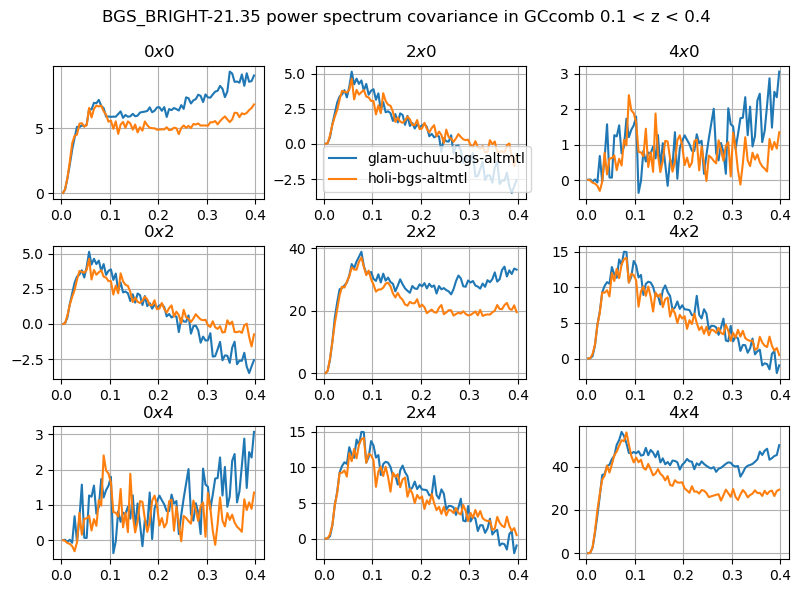

Shotnoise is 1977+-8
Shotnoise is 1884+-7


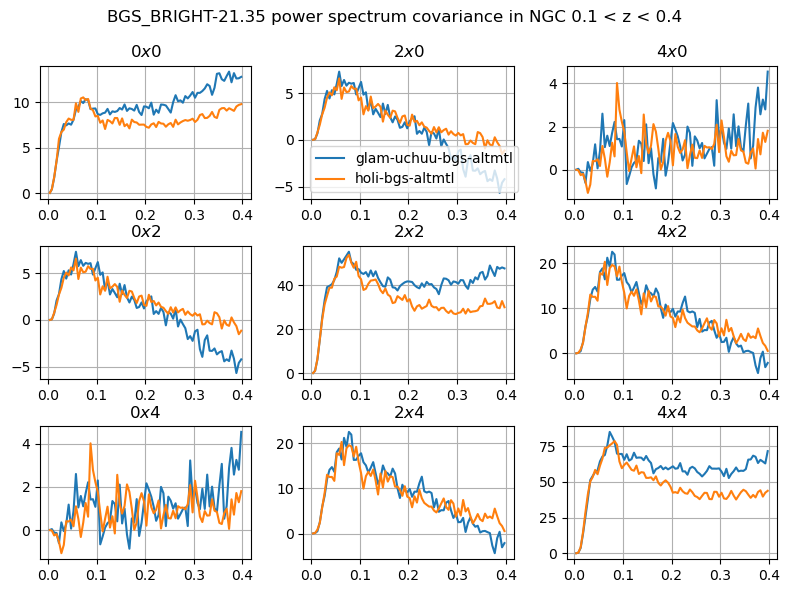

Shotnoise is 2177+-16
Shotnoise is 2079+-15


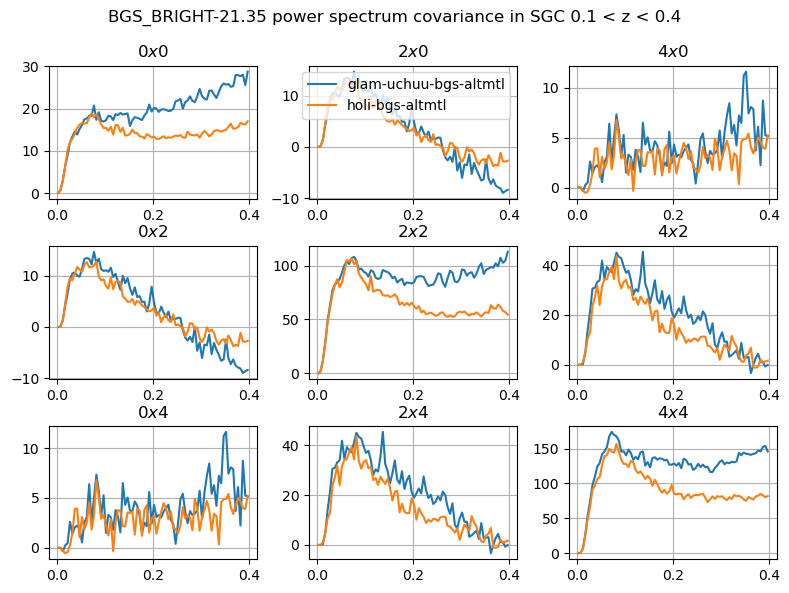

In [13]:
# now plot covariance
kind = 'mesh2_spectrum'
pp = PdfPages(plot_dir / 'check_covariance_diagonals_glam_and_holi_bright.pdf')
for tracer in tracers:
    for region in regions:
        zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
        for iz, zrange in enumerate(zranges): 
            stats_kws = dict(stats_dir=stats_dir, tracer=tracer, project=project, zrange=zrange, region=region, weight='default-FKP')
            plot_covariance_checks(kind, glam_imocks, version_set1, holi_imocks, version_set2, **stats_kws)
            
            fig = plt.gcf()
            pp.savefig(fig,bbox_inches='tight')
            plt.show()
pp.close()